In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
# Setup dimensions: batch_size=2, sequence_length=4, embedding_dim=8
batch_size = 2
seq_len = 4
embed_dim = 8
num_heads = 2

# PyTorch expects batch_first=True for easier handling
attn_layer = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=num_heads, batch_first=True)

# Dummy input sequence (e.g., embeddings of 4 tokens for 2 sentences)
x = torch.randn(batch_size, seq_len, embed_dim)

# For self-attention, Q, K, and V are all the same input tensor 'x'
# Setting average_attn_weights=False keeps the heads separate
output, attention_weights = attn_layer(x, x, x, need_weights=True, average_attn_weights=False)

print("Input shape:", x.shape)
print("Attention weights shape:", attention_weights.shape) 
# Shape will be: (batch_size, num_heads, target_seq_len, source_seq_len)
# e.g., torch.Size([2, 2, 4, 4])

Input shape: torch.Size([2, 4, 8])
Attention weights shape: torch.Size([2, 2, 4, 4])


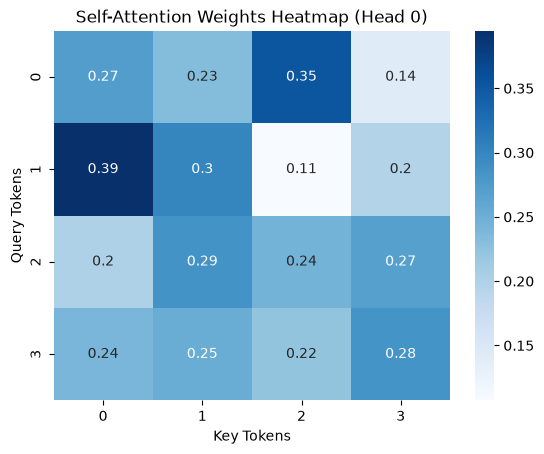

In [5]:
# Grab batch 0, attention head 0 -> results in a 2D shape of (seq_len, seq_len)
sample_weights = attention_weights[0, 0].detach().numpy()

sns.heatmap(sample_weights, annot=True, cmap="Blues", cbar=True)
plt.title("Self-Attention Weights Heatmap (Head 0)")
plt.xlabel("Key Tokens")
plt.ylabel("Query Tokens")
plt.show()

In [12]:
# Let's assume input X has shape: (seq_len, embed_dim)
seq_len, embed_dim = 4, 8
X = torch.randn(seq_len, embed_dim)

# Define linear weights for Query, Key, and Value
W_q = torch.randn(embed_dim, embed_dim)
W_k = torch.randn(embed_dim, embed_dim)
W_v = torch.randn(embed_dim, embed_dim)

# 1. Project inputs to Q, K, V
Q = X @ W_q
K = X @ W_k
V = X @ W_v

# 2. Compute raw attention scores (dot product of Q and transposed K)
# Scaled by the square root of the head dimension to keep gradients stable
d_k = embed_dim
scores = (Q @ K.transpose(-2, -1)) / (d_k ** 0.5)

# 3. Apply Softmax to get probabilities (The Attention Map)
attention_weights = F.softmax(scores, dim=-1)

# 4. Multiply by Values to get the final context-aware representation
context_vector = attention_weights @ V

print("Custom Attention Weights Shape:", attention_weights.shape) 
# Shape: (seq_len, seq_len) -> e.g., torch.Size([4, 4])

Custom Attention Weights Shape: torch.Size([4, 4])


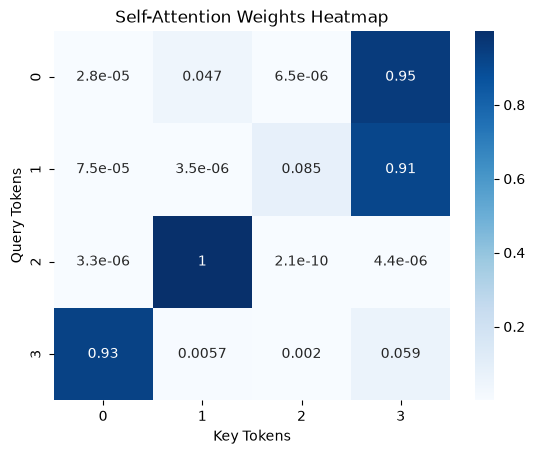

In [13]:
# Pass the 2D tensor directly without indexing
sns.heatmap(attention_weights.detach().numpy(), annot=True, cmap="Blues", cbar=True)
plt.title("Self-Attention Weights Heatmap")
plt.xlabel("Key Tokens")
plt.ylabel("Query Tokens")
plt.show()